# Task 1: Binary Classification with Perceptron

In this notebook we build a simple example of **binary classification** in the plane.

The idea is the following: we generate random points \((x,y)\), choose a random line, and assign a label depending on which side of the line the point lies.

- class `1` if the point lies on a side of the line;
- class `0` if the point lies on the other side of the line.

We then train a small neural network (a perceptron) to learn this separation automatically from the data.

## Importing the Libraries

We import the following python libraries 
- `PyTorch` is the main library used to construct and train the model,
- `NumPy` and `pandas` are used to process data, 
- `Matplotlib` is used to visualise the data.

In [13]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
#import os

## Generating the Dataset

To create a binary classification problem, we first choose a random line

$$y =mx+q.$$

This line divides the plane into two regions.

Then, we will generate 1000 random point in the square $[-1,1] \times [-1,1]$. For each point, we check on which side of the line it lies and assign the corresponding class label.

In [14]:
# We generate 2 random numbers to create a line
m = torch.randn(1).item()
#q = torch.randn(1).item()
q = 2 * torch.rand(1).item() - 1

print(f" y = {m:.3f} x {q:+.3f}")

# We generate the 500 points
N = 500
X = 2 * torch.rand(N, 2) - 1   # points in [-1,1] x [-1,1]

# Coordinate
x_coords = X[:, 0]
y_coords = X[:, 1]


line_y = m * x_coords + q

# Labels
y = (y_coords > line_y).float().view(-1, 1)

 y = 0.206 x -0.645


## Data Visualization

The plot shows the generated points inside the square $[-1,1] \times [-1,1]$.

The colors represent the two classes. If the dataset has been generated correctly, we should observe two regions separated approximately by a straight line.

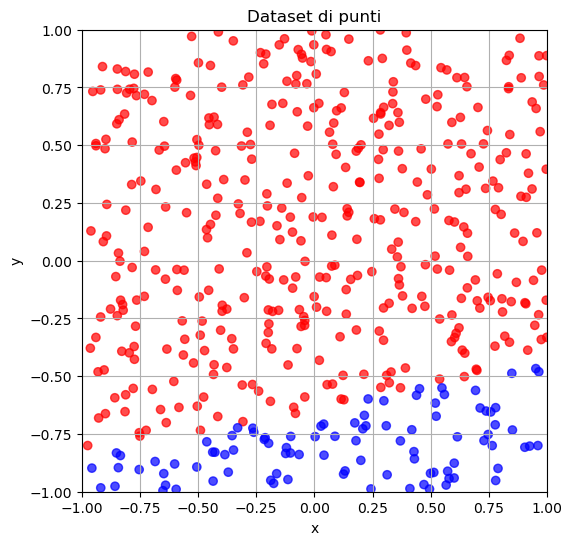

In [15]:
plt.figure(figsize=(6,6))

# points colored in base on the class
plt.scatter(
    X[:, 0],          # coordinate x
    X[:, 1],          # coordinate y
    c=y.view(-1),     # colors 
    cmap="bwr",       # blue/red
    alpha=0.7
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Dataset di punti")
plt.grid(True)

plt.xlim(-1, 1)
plt.ylim(-1, 1)

plt.show()

We are choosing 400 random points to train on 

In [16]:
# Randomly choose 400 points for training
training_indices = torch.randperm(N)[:1]

# Training subset
X_train = X[training_indices]
y_train = y[training_indices]

print(X_train.shape, y_train.shape)

torch.Size([1, 2]) torch.Size([1, 1])


## Defining and Training the Perceptron

The model used here is a very simple perceptron:

1. a linear layer `Linear(2, 1)`, which takes the two coordinates of the point as input;
2. a `Sigmoid` activation function, which converts the output into a probability between 0 and 1.

During training, the model updates its parameters to minimize the classification error on the dataset.

In [17]:
# We define the model
model = torch.nn.Sequential(
    torch.nn.Linear(2, 1),
    torch.nn.Sigmoid(),

)

# Loss and optimizer
loss_fn = torch.nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

# Lists to save the losses
training_loss_history = []
total_loss_history = []

# Training
epochs = 10000

for epoch in range(epochs):

    # Prediction on training set
    y_pred_train = model(X_train)

    # Training loss
    train_loss = loss_fn(y_pred_train, y_train)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    # Total loss on the full dataset
    with torch.no_grad():
        y_pred_total = model(X)
        total_loss = loss_fn(y_pred_total, y)

    # Save losses
    training_loss_history.append(train_loss.item())
    total_loss_history.append(total_loss.item())

    if epoch % 100 == 0:
        print(
            f"Epoch {epoch}, "
            f"training loss = {train_loss.item():.4f}, "
            f"total loss = {total_loss.item():.4f}"
        )

Epoch 0, training loss = 0.4526, total loss = 0.6918
Epoch 100, training loss = 0.0726, total loss = 0.5472
Epoch 200, training loss = 0.0376, total loss = 0.5638
Epoch 300, training loss = 0.0252, total loss = 0.5825
Epoch 400, training loss = 0.0189, total loss = 0.5989
Epoch 500, training loss = 0.0151, total loss = 0.6132
Epoch 600, training loss = 0.0126, total loss = 0.6257
Epoch 700, training loss = 0.0108, total loss = 0.6368
Epoch 800, training loss = 0.0094, total loss = 0.6467
Epoch 900, training loss = 0.0084, total loss = 0.6558
Epoch 1000, training loss = 0.0075, total loss = 0.6641
Epoch 1100, training loss = 0.0068, total loss = 0.6717
Epoch 1200, training loss = 0.0063, total loss = 0.6788
Epoch 1300, training loss = 0.0058, total loss = 0.6854
Epoch 1400, training loss = 0.0054, total loss = 0.6915
Epoch 1500, training loss = 0.0050, total loss = 0.6974
Epoch 1600, training loss = 0.0047, total loss = 0.7028
Epoch 1700, training loss = 0.0044, total loss = 0.7080
Epoc

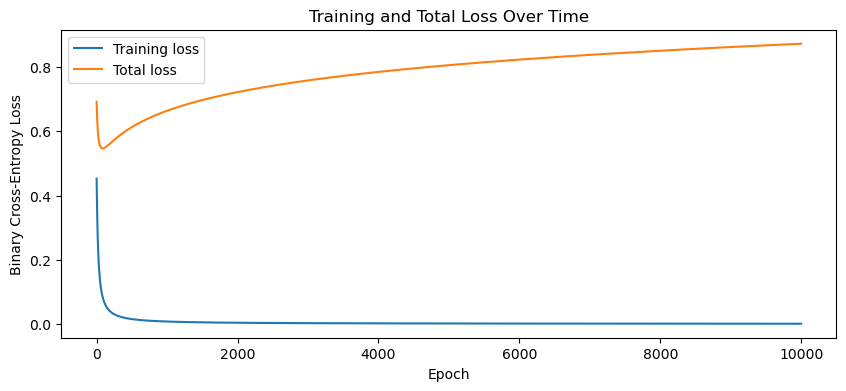

In [18]:
# Plot the loss functions
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(training_loss_history, label='Training loss')
ax.plot(total_loss_history, label='Total loss')

ax.set_xlabel('Epoch')
ax.set_ylabel('Binary Cross-Entropy Loss')
ax.set_title('Training and Total Loss Over Time')

ax.legend()

plt.show()

## Comparison with the Original Line

After training, the linear layer of the model has learned a new line of the form


$$w_1x + w_2y + b = 0.$$


This is the **decision boundary** learned by the perceptron.

We can compare it with the original line used to generate the dataset to see how accurately the model learned the classification rule.

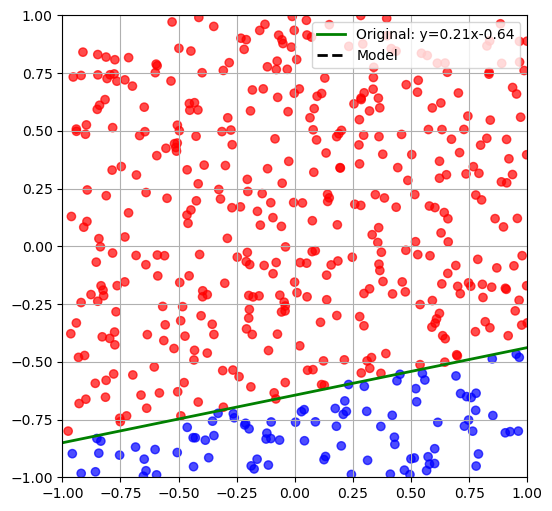

In [20]:
with torch.no_grad():
    w1, w2 = model[0].weight[0]
    b = model[0].bias[0]
    y_model = -(w1 * x_vals + b) / w2

x_vals = torch.linspace(-1, 1, 200)
y_original = m * x_vals + q

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=y.view(-1), cmap="bwr", alpha=0.7)
plt.plot(x_vals, y_original, color="green", linewidth=2, label=f"Original: y={m:.2f}x{q:+.2f}")
plt.plot(x_vals, y_model, color="black", linewidth=2, linestyle="--", label="Model")
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.legend()
plt.grid(True)
plt.show()

## Final Remarks

This example works well because the two classes are separated by a straight line.

A single perceptron can only learn **linear** separations.

If the data were not linearly separable, we would need a more complex neural network with additional hidden layers and nonlinear activation functions.

# Questions
Before proceeding, try to answer to the next questions
1. Why does the network use Linear(2,1)?
2. What is the role of the Sigmoid activation function?
3. What is the purpose of the loss function?
4. What does it mean if the loss stops decreasing?
5. What might happen if we trained on only 10/50/100 points? (Try!)
6. Think of an example of a dataset that cannot be separated by a single straight line.
7. Train the model for 50, 500, and 5000 epochs. What changes?
8. Replace the learning rate with a much larger value. What happens to the loss?

# Task 2: Classification of Annuli with a Neural Network

In this part of the notebook we study a more difficult binary classification problem than the previous perceptron example.

Instead of separating points with a straight line, the dataset is composed of two concentric regions (annuli/rings). The goal is to train a neural network capable of learning a **nonlinear decision boundary**.

This example highlights one of the main limitations of a single perceptron: it can only learn linear separations.

## Difference from the Previous Task

In the previous task:
- the two classes were separated by a straight line;
- a single perceptron was sufficient;
- the problem was linearly separable.

In this notebook:
- the classes form circular or annular regions;
- the separation boundary is nonlinear;
- we need a deeper neural network with hidden layers and activation functions.

This proves why multilayer neural networks are gnerally more powerful than a single perceptron.

## Importing the Libraries

We import the following python libraries 
- `PyTorch` is the main library used to construct and train the model,
- `NumPy` is used to process data, 
- `Matplotlib` is used to visualise the data.
- `Random` utilities for sampling training batches.

In [ ]:
import random
import torch
from torch import nn, optim
import matplotlib.pyplot as plt
import numpy as np
import math

## Generating the Dataset

The dataset consists of points in the plane divided into two categories:
- points inside a certain annular region;
- points outside it.

Because the boundary is curved, the classes cannot be separated by a single straight line.

In [ ]:
r0, r1, r2, r3 = 0.5, 1.0, 1.5, 2.1
number = 1000

def generate_annulus(r_inner, r_outer, number=1000):
    r = np.random.uniform(low=r_inner**2, high=r_outer**2, size=number)**0.5
    theta = np.random.uniform(low=0.0, high=2*math.pi, size=number)
    return torch.tensor(np.column_stack([r * np.cos(theta), r * np.sin(theta)])).float()
  

points = torch.concat([generate_annulus(r0, r1, number), generate_annulus(r2, r3, number)])

categories = torch.concat([torch.full(size=(number,), fill_value=0), torch.full(size=(number,), fill_value=1)])

points.shape, categories.shape

## Visualising the Dataset

The plot shows the two classes distributed in concentric regions.

In [ ]:
def setup_annuli_plot():
    fig, ax = plt.subplots(figsize=(5, 5))
    axislim = r3 + 0.5
    ax.set_xlim([-axislim, axislim])
    ax.set_ylim([-axislim, axislim])
    return ax


ax = setup_annuli_plot()
ax.scatter(x=points[:,0], y=points[:,1],cmap="bwr", c=categories, marker='.')
ax.set_title('All data')
plt.show()

We randomly select 500 points from the dataset to create the training set used during learning.
The remaining points are not used for training and can be used to evaluate how well the model generalizes to unseen data.

In [ ]:
# A vector of 500 numbers, chosen without replacement, from the range [0, 2000).
training_indices = torch.randperm(2000)[:500]

# Vectors of integers can be used to index other vectors, picking out the points
# at that index. We use this to pick out a subset of the data to use for training.
training_points = points[training_indices, :]
training_categories = categories[training_indices]

training_points.shape, training_categories.shape

## Neural Network Architecture

The model used here is more complex than a single perceptron.

The network contains:
- an input layer with 2 coordinates $(x,y)$;
- a hidden layer with nonlinear activation functions (`nn.ReLU`);
- an output layer producing the class scores.

The hidden layer allows the model to learn nonlinear decision boundaries.

### For an interactive visual example: [TensorFlow Playground](https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4,2&seed=0.01382&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false)

## Training Procedure

The network is trained using:
- `CrossEntropyLoss` as the loss function;
- `SGD` (Stochastic Gradient Descent) as the optimizer.

At each epoch:
1. a random batch of points is selected;
2. the model computes predictions;
3. the loss is evaluated;
4. gradients are computed using backpropagation;
5. the parameters are updated.

In [ ]:
annuli_model = nn.Sequential(
    # To insert a ReLu layer between linear layers: "nn.ReLU(),"
    ...
    ...
    ...
)

def train_annuli(model, number_epochs):
    loss_function = nn.CrossEntropyLoss()
    optimiser = optim.SGD(model.parameters(), lr=0.01, momentum=0.01)
    training_loss = torch.zeros(number_epochs)
    total_loss = torch.zeros(number_epochs)

    for epoch in range(number_epochs):
        # Per epoch, we select a random batch of 10 elements of the training data
        # to evaluate the network on.
        batch = torch.tensor(random.sample(range(500), k=10))
        
        optimiser.zero_grad()
        model_output = model(training_points[batch])
        loss = loss_function(model_output, training_categories[batch])
        loss.backward()
        optimiser.step()
        
        # Keep track of the training and total loss of the network at each epoch.
        training_loss[epoch] = loss_function(model(training_points), training_categories)
        total_loss[epoch] = loss_function(model(points), categories)

        if epoch % 1000 == 999:
            print(f"At epoch {epoch}, the training loss is {training_loss[epoch]:.2f}, the total loss is {total_loss[epoch]:.2f}")
    
    return training_loss.detach(), total_loss.detach()

training_loss, total_loss = train_annuli(annuli_model, 8000)

In [ ]:
# Show how the loss function changed over time.
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(training_loss, label='Training loss')
ax.plot(total_loss, label='Total loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('Training for the annuli model')
ax.legend()
plt.plot()

In [ ]:
def plot_true_vs_predicted(model, points, categories):
    model.eval()

    with torch.no_grad():
        predicted = torch.argmax(model(points), dim=1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.scatter(points[:, 0], points[:, 1], c=categories, cmap="bwr", alpha=0.7)
    plt.title("Real classes")
    plt.axis("equal")
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.scatter(points[:, 0], points[:, 1], c=predicted, cmap="bwr", alpha=0.7)
    plt.title("Predicted classes")
    plt.axis("equal")
    plt.grid(True)

    plt.show()

In [ ]:
plot_true_vs_predicted(annuli_model, points, categories)

## Final Remarks

This notebook shows that multilayer neural networks can solve problems that are impossible for a single perceptron.

By adding hidden layers and nonlinear activation functions, neural networks can approximate much more complicated decision boundaries, including circular and annular shapes.

In the previous excercise we have worked in the precise setting where 
$$r_0 < r_1 < r_2 < r_3. $$
In this setting the two regions are clearly separable. 
- What if $r_1=r_2$?
- What if $r_1 > r_2$?


There is a fun webpage to play with: https://playground.tensorflow.org/

# Questions
Before proceeding, try to answer to the next questions
1. What is the role of the ReLU function? Would the model work without it? 
2. What might happen if we trained on only 10/50/100 points? (Try!)
3. Train the model for 50, 500, and 5000 epochs. What changes?